# 📄 Comprehensive Document Analyzer

**Concepts Combined:**
- Document loading (PDF/TXT)
- Smart chunking (RecursiveCharacterTextSplitter)
- Embeddings & FAISS vector store
- Semantic search with relevance scores
- Structured entity extraction (Pydantic + NER)
- Downloadable report

**Interface:** Built with **Streamlit** – a pure‑Python web framework.

## 🔧 Technologies & Choices

| Tool | Purpose | Why This? |
|------|---------|-----------|
| **LangChain** | Document loaders, text splitters, vector store wrapper | High‑level, modular, works with many backends |
| **HuggingFace Embeddings** (`all-MiniLM-L6-v2`) | Converts text → vectors | Fast, local, no API cost |
| **FAISS** | Vector similarity search | Efficient, in‑memory, exact / approximate |
| **Transformers (NER)** | Entity extraction (`dslim/bert-base-NER`) | Accurate, local, no external API |
| **Pydantic** | Schema for extracted entities | Type safety, automatic serialisation |
| **Streamlit** | Frontend | No HTML/JS needed, reactive, perfect for demos |

## 🎈 How Streamlit Works

- **Script‑based execution:** Every user interaction re‑runs the entire Python script **from top to bottom**.
- **Caching:** `@st.cache_resource` stores heavy objects (models) across reruns.
- **Widgets:** `st.file_uploader`, `st.button`, `st.text_input` generate UI elements that return values.
- **State management:** `st.session_state` persists data between reruns.

**Why Streamlit for this project?**
- Zero frontend code – all UI is declared in Python.
- Built‑in support for progress bars, spinners, error messages.
- Instant deployment with `streamlit run`.

In [ ]:
# Core imports
import os, tempfile, re
from typing import List

# LangChain
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# NER & Pydantic
from transformers import pipeline
from pydantic import BaseModel, Field

# (Streamlit is imported only in the final app – not needed for these cells)

## 📄 Step 1: Document Loading & Chunking

- Use `PyPDFLoader` or `TextLoader` to extract text.
- `RecursiveCharacterTextSplitter` breaks text into overlapping chunks:
  - `chunk_size=1000` characters
  - `chunk_overlap=200` (keeps context across chunks)
  - Separators: paragraphs, newlines, sentences, spaces.
- Empty text detection: if `full_text.strip() == ""`, raise an error (scanned PDF).

In [ ]:
# Simulate loading a sample text (replace with your own file path)
sample_text = """
The quick brown fox jumps over the lazy dog. John works at OpenAI in San Francisco.
The project started on 12/05/2023 and is led by Dr. Smith. The main goal is to build
a system that understands natural language. Microsoft and Google are partners.
"""

# Write to a temp file
with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as f:
    f.write(sample_text)
    tmp_path = f.name

# Load
loader = TextLoader(tmp_path)
docs = loader.load()
full_text = " ".join([d.page_content for d in docs])
print(f"Extracted {len(full_text)} characters\n{full_text[:200]}...")

# Chunk
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300, chunk_overlap=50,
    separators=["\n\n", "\n", ".", "?", "!", " ", ""]
)
chunks = splitter.split_text(full_text)
print(f"\nNumber of chunks: {len(chunks)}")
print("First chunk:", chunks[0])

os.unlink(tmp_path)  # clean up

## 🧠 Step 2: Embeddings & FAISS

- **Embeddings:** `HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")`  
  Transforms each chunk into a 384‑dimensional vector.
- **FAISS:** Fast library for similarity search.  
  `FAISS.from_texts(chunks, embeddings)` builds an index.
- All computation runs **locally** – no internet required after model download.

In [ ]:
# Load the embedding model (first time downloads ~80MB)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Build FAISS index from chunks
vectorstore = FAISS.from_texts(chunks, embeddings)
print("FAISS index created with", vectorstore.index.ntotal, "vectors")

## 🔍 Step 3: Semantic Search

- User enters a query → embedded into the same vector space.
- `vectorstore.similarity_search_with_score(query, k=3)` returns top‑k chunks with L2 distance.
- **Relevance score**: `1 / (1 + L2_distance)` gives a 0–1 score.
- Results are displayed with snippet and score.

In [ ]:
query = "Who works at OpenAI?"
k = 2

results = vectorstore.similarity_search_with_score(query, k=k)
for i, (doc, score) in enumerate(results):
    relevance = round(1 / (1 + score), 4)
    print(f"Result {i+1} (relevance: {relevance}):")
    print(doc.page_content[:300])
    print("-" * 50)

## 🧾 Step 4: Structured Extraction (Pydantic + NER)

- **Pydantic schema** defines entities: `persons`, `organizations`, `locations`, `dates`, `key_terms`.
- **NER pipeline** (`dslim/bert-base-NER`) extracts PER, ORG, LOC tags.
- **Regex** catches common date patterns.
- The extracted data is stored in a Pydantic model and displayed as JSON.
- The NER model runs on the first 2000 characters to keep it fast.

## 🚀 Putting It All Together – The Streamlit App

The final application (`app.py`) combines all the above steps into an interactive dashboard.

### Key Streamlit Features Used:
- **Caching:** `@st.cache_resource` loads models once.
- **Widgets:** `file_uploader`, `text_input`, `slider`, `button`, `expander`.
- **Session State:** Persists chunks, vectorstore, and extracted entities.
- **Feedback:** `st.success`, `st.error`, `st.warning`, `st.spinner`.

### How to Run:
```bash
pip install streamlit langchain langchain-community langchain-text-splitters langchain-huggingface pypdf sentence-transformers faiss-cpu transformers torch pydantic
streamlit run app.py

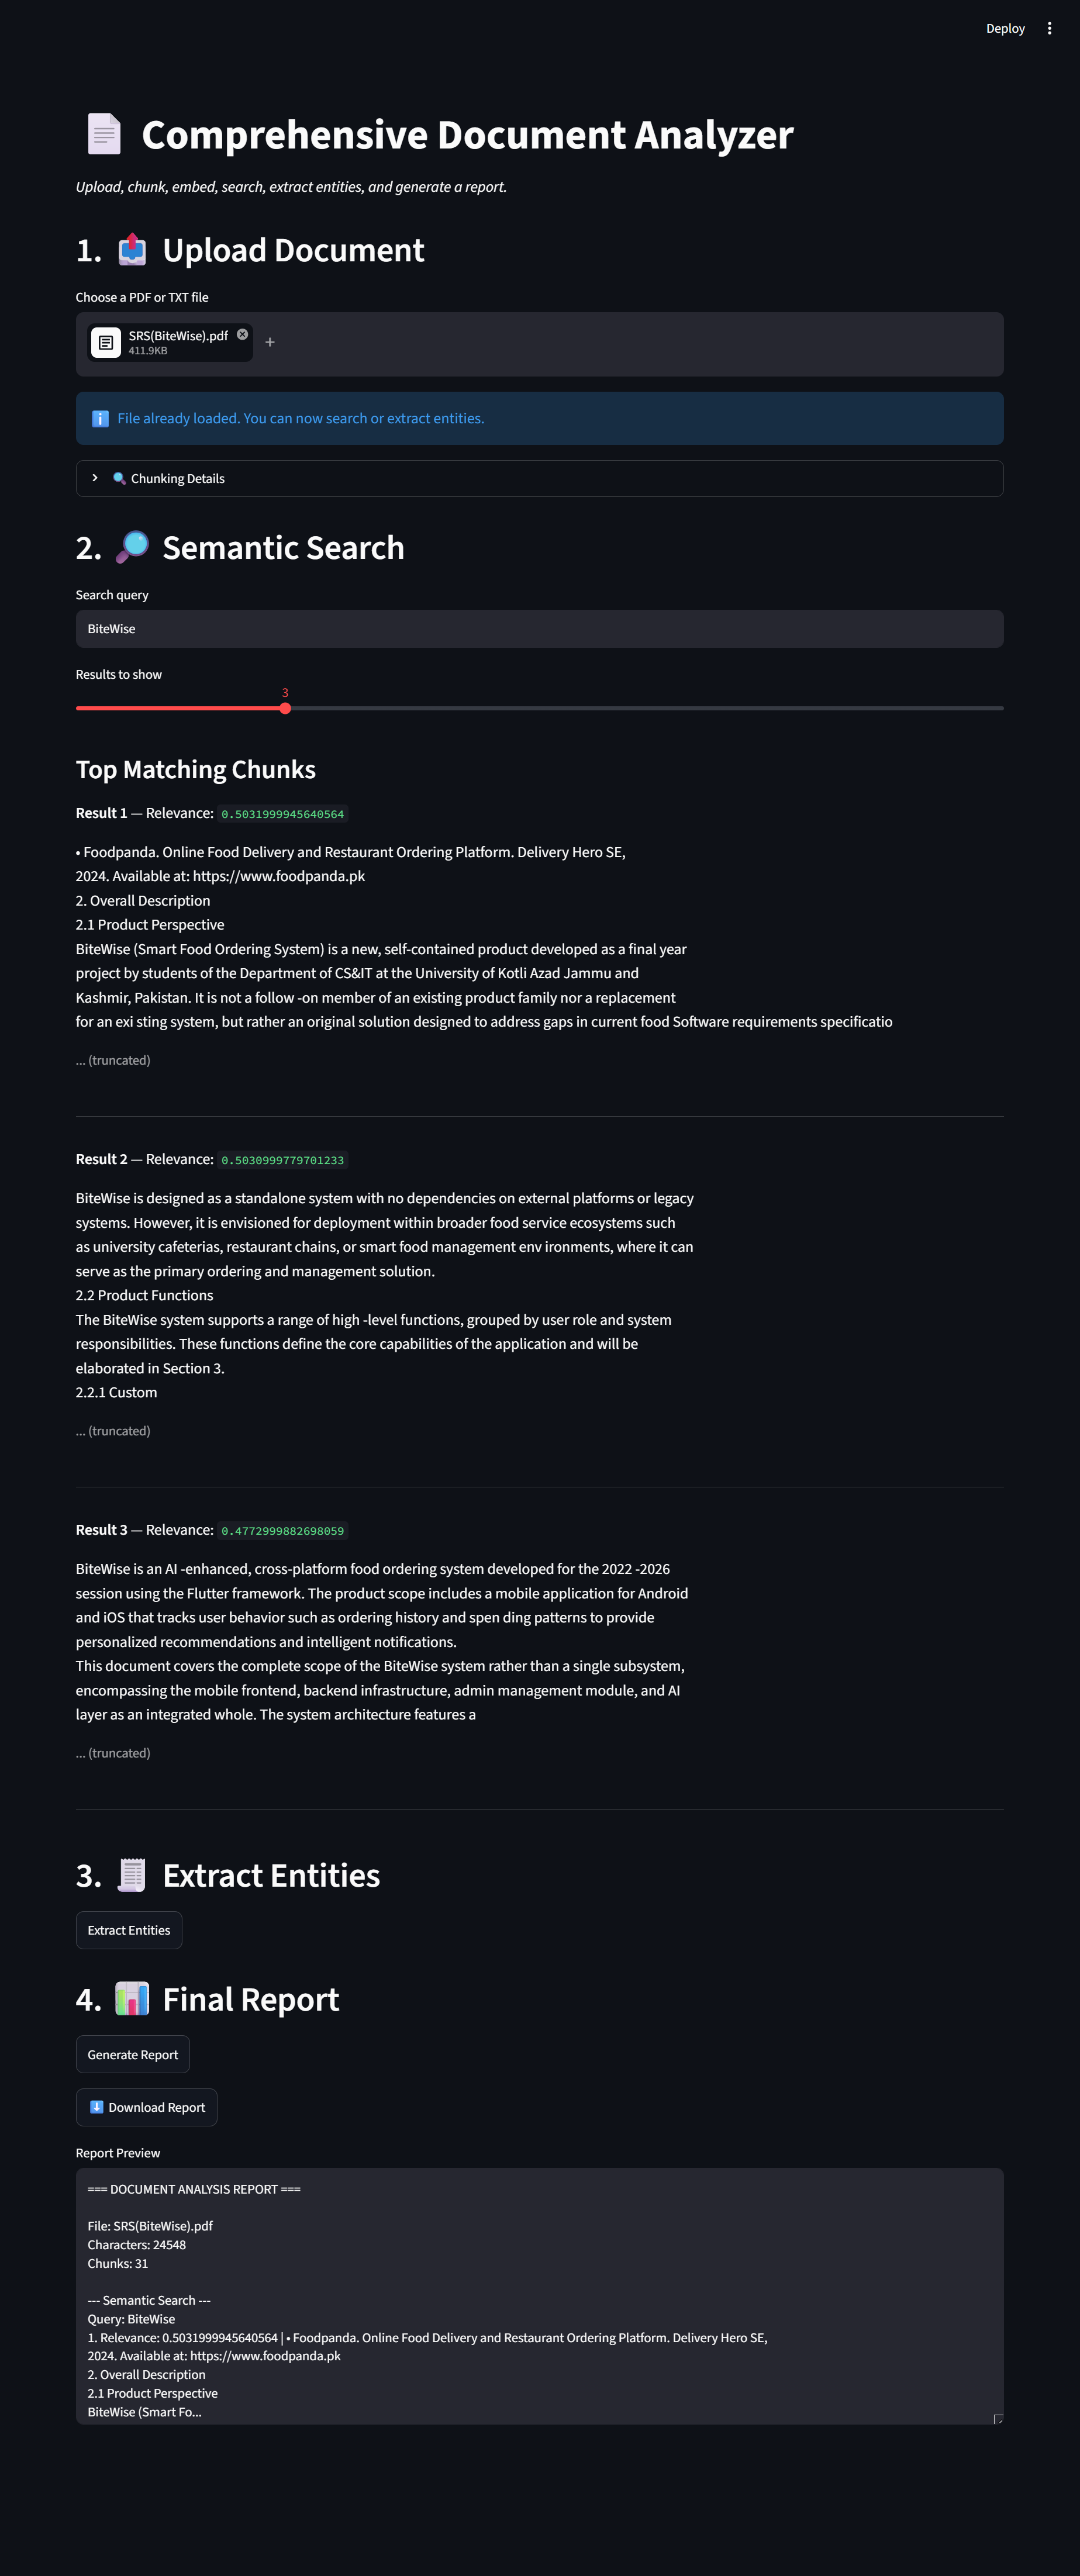
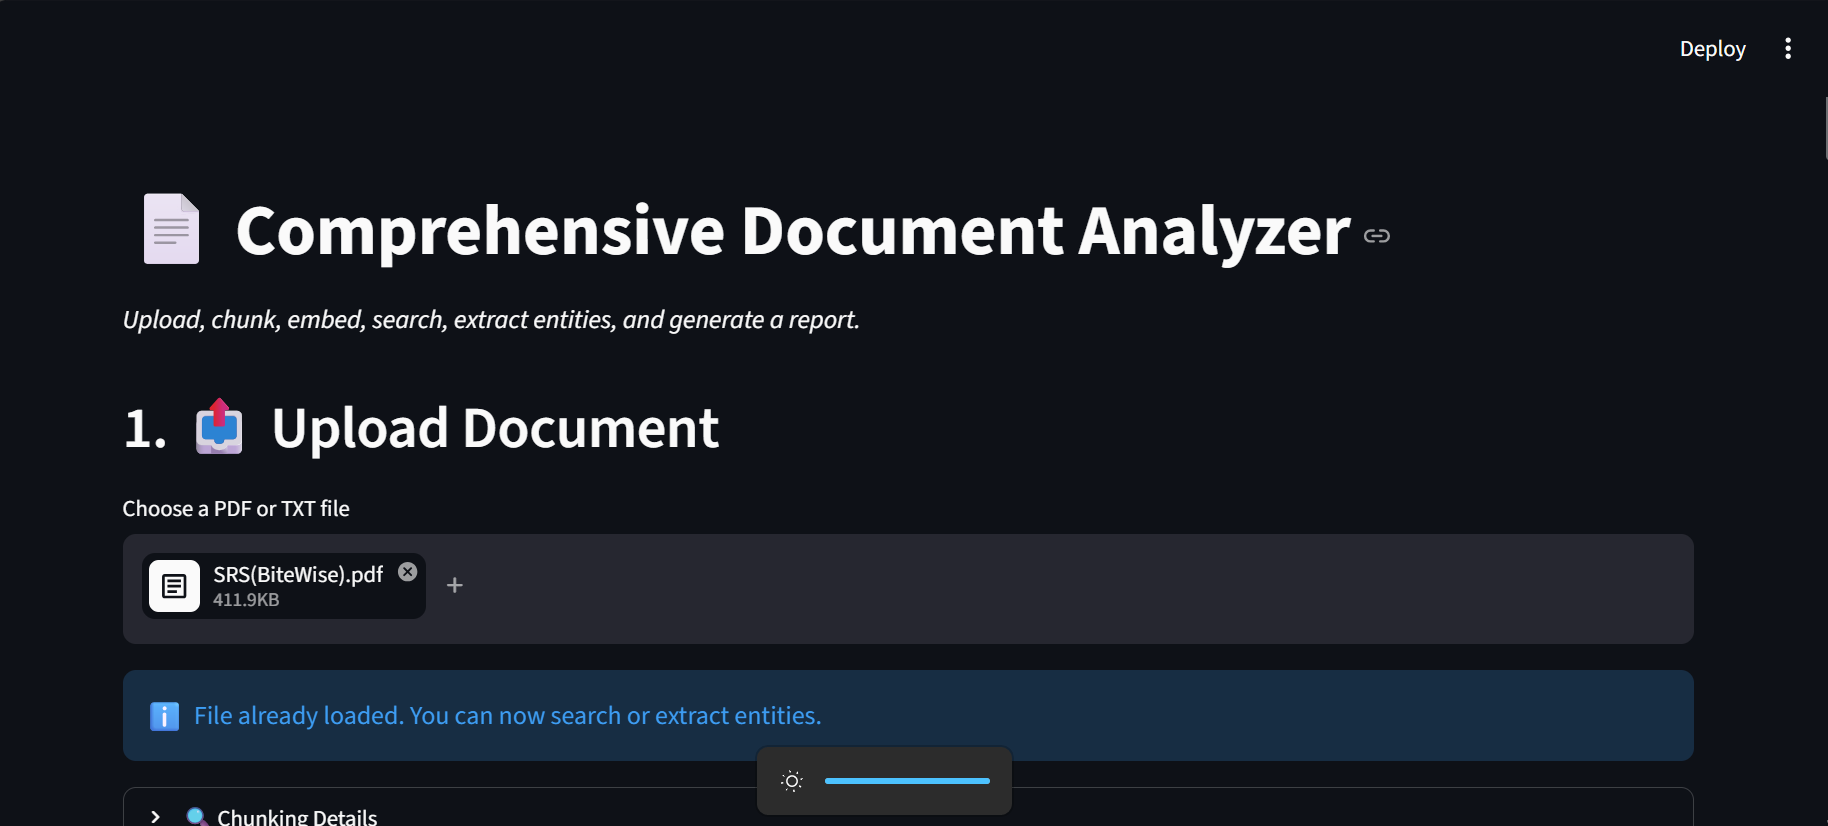


### **Conclusion**

## ✅ Summary

I built a complete document analysis pipeline that demonstrates:

- **Smart chunking** with `RecursiveCharacterTextSplitter`
- **Vector search** using HuggingFace embeddings and FAISS
- **Structured extraction** with a local NER model and Pydantic
- **User‑friendly interface** with Streamlit

All components run **locally** – no API keys required.  
The notebook you just walked through explains every building block.  
The final `app.py` script wraps everything into a single, deployable web app.